#Upload metrics.json (from results)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving metrics.json to metrics.json


# Loading + Inspect Data

In [2]:
import json
import pandas as pd

# Load JSON
with open("metrics.json", "r") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data).T

# Keep only important metrics
metrics = ["mAP50", "mAP50-95", "precision", "recall"]
df = df[metrics]

df

,mAP50,mAP50-95,precision,recall
baseline,0.293737,0.166267,0.391599,0.302583
cbam,0.302069,0.172701,0.414643,0.302483
pseudo_label,0.307239,0.175545,0.41857,0.311933
yolov11n_baseline,0.265176,0.147555,0.388175,0.30119
yolo26n_baseline,0.249414,0.137379,0.367711,0.291035


# Generate bar graph

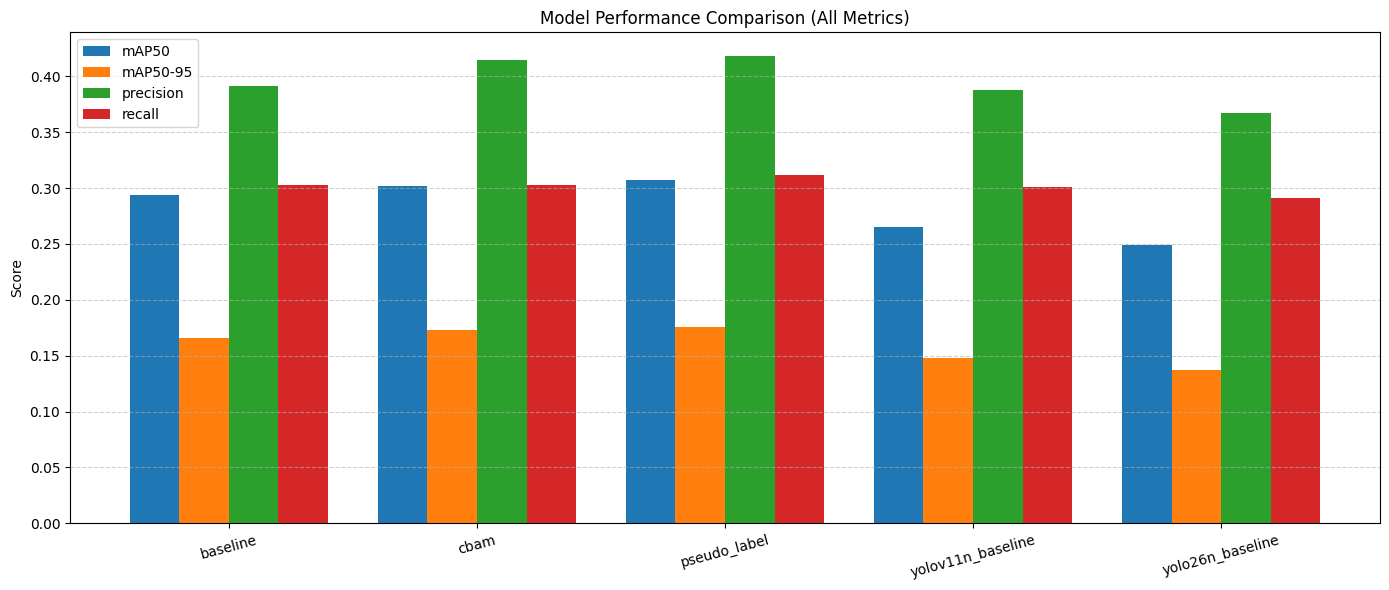

In [4]:
import matplotlib.pyplot as plt
import numpy as np

models = df.index.tolist()
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df[metric], width, label=metric)

plt.xticks(x + width*1.5, models, rotation=15)
plt.ylabel("Score")
plt.title("Model Performance Comparison (All Metrics)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
baseline = df.loc["baseline"]

improvement = ((df - baseline) / baseline) * 100
improvement = improvement.round(2)

improvement

,mAP50,mAP50-95,precision,recall
baseline,0.0,0.0,0.0,0.0
cbam,2.836595,3.869417,5.884663,-0.032989
pseudo_label,4.596883,5.579833,6.887383,3.090022
yolov11n_baseline,-9.723145,-11.254435,-0.874457,-0.460436
yolo26n_baseline,-15.089125,-17.374583,-6.100151,-3.816468


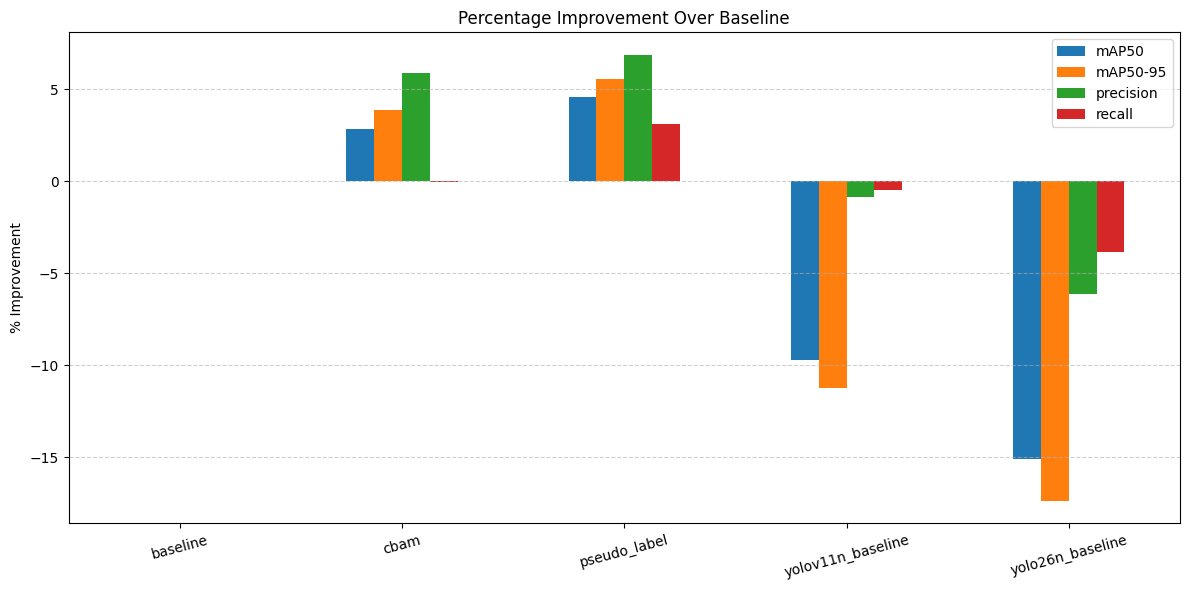

In [12]:
improvement.plot(kind='bar', figsize=(12,6))

plt.title("Percentage Improvement Over Baseline")
plt.ylabel("% Improvement")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path('results/metrics.json')
with open(metrics_path, 'r', encoding='utf-8') as f:
    all_metrics = json.load(f)

key_order = ['baseline', 'cbam', 'eca', 'svgc', 'pseudo_label', 'yolov11n_baseline', 'yolo26n_baseline']
labels = ['YOLOv8n\nBaseline', 'YOLOv8n\n+CBAM', 'YOLOv8n\n+ECA', 'YOLOv8n\n+SVGC', 'YOLOv8n\n+Pseudo', 'YOLOv11n\nBaseline', 'YOLO26n\nBaseline']
colors = ['#3498db', '#e74c3c', '#1abc9c', '#e67e22', '#9b59b6', '#f39c12', '#2ecc71']

plot_labels = []
plot_map50 = []
plot_colors = []

for key, label, color in zip(key_order, labels, colors):
    if key in all_metrics:
        plot_labels.append(label)
        plot_map50.append(all_metrics[key]['mAP50'])
        plot_colors.append(color)

plt.figure(figsize=(12, 6))
bars = plt.bar(plot_labels, plot_map50, color=plot_colors, width=0.5)
plt.ylabel('mAP@50', fontsize=12)
plt.title('VisDrone Detection: All Models Comparison', fontsize=14)
plt.ylim(0, max(plot_map50) * 1.2 if plot_map50 else 1)
for bar, v in zip(bars, plot_map50):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results/all_progressions_extended.png', dpi=150)
plt.show()


In [ ]:
import pandas as pd

data = []
baseline_val = all_metrics.get('baseline', {}).get('mAP50', 0)

for key, label in zip(key_order, labels):
    if key in all_metrics:
        m = all_metrics[key]
        delta = m['mAP50'] - baseline_val
        delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
        data.append({
            'Model': label.replace('\n', ' '),
            'mAP@50': m.get('mAP50', 0),
            'mAP@50-95': m.get('mAP50-95', 0),
            'Precision': m.get('precision', 0),
            'Recall': m.get('recall', 0),
            'Delta-from-baseline': delta_str
        })

df = pd.DataFrame(data)
display(df)
df.to_csv('results/ablation_table.csv', index=False)
